# Advection-Reaction-Diffusion PDEs

In [1]:
import torch
from torch.utils.data import TensorDataset, ConcatDataset, Subset
from torch import Tensor
from data_utils import X, U, TIMES, compute_prediction_difference, compute_prediction, extract_targets, extract_TensorDataset, extract_boundary
from plot_utils import plot_loss_comp, plot_model_stats, print_model_info, plot_points_grid, plot_model_stats_grid, print_model_performances, plot_model_performances, get_animation, plot_performance_comparison, plot_loss, plot_time_losses
from load_store_utils import load_stats, resume_model
from train import start_train
from typing import List
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm import tqdm
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ----------------------
TRAIN = False
START_TRAIN_STEP = 0
SAVE_PLOTS = True
CROSS_THE_RUBICON = False

PDE = "AdvectionReactionDiffusion/ConvectionSlow"
PDE_NAME = "Advection-Reaction-Diffusion"
SEED = 42

FIXED = ["IC", "D"]
IC_INDEX = 0
D_INDEX = 0
INDEX = 0
IC = 0 # only if all or nothing fixed
D = 0 # only if all or nothing fixed

N_SOURCES = 5

GENERATION_BC = "Neumann" # Dirichlet Neumann

N_TIME_SAMPLES = 10
TRAIN_TIME_INDEXESS = [[0, i-1, i] for i in range(1, 10, 2)] #[[i-1, i] for i in range(1, 10, 2)] #[[i] for i in range(1, 10)]
TIME_RESOLUTION = 1
TIME_SAMPLING = "Const" # Const Log

ACTUAL_MODE = "PINN" # Output Output+PINN Output+Derivative Output+Derivative+Hessian 
N_EPOCHS = 200
LR_MODE = "CosAnn" # CosAnn ExpDec

ACTUAL_MODE0 = "PINN"
N_EPOCHS0 = N_EPOCHS
LR_MODE0 = LR_MODE

N_EPOCHS_FULL = 400

#SHAPE = {"shape": "circle", "cell_size": 0.02, "center": [0.0, 0.0], "radius": 1.0}
SHAPE = {"shape": "rectangle"}

#SHAPE0 = {"shape": "circle", "cell_size": 0.02, "center": [0.0, 0.0], "radius": 1.0}
SHAPE0 = {"shape": "rectangle"}

BC_MODE = "Global" # Local
IC_MODE = "Separated" # Separated Excluded Joined
TRAIN_BC = "Neumann" # Dirichlet Neumann
PDE_AT_BD = False
PDE_AT_T0 = True

BC_MODE0 = BC_MODE
IC_MODE0 = IC_MODE

IC_PARAMS_IN_INPUT = False
PDE_PARAMS_IN_INPUT = False

DWA_MODE = "Std"
CLIP_GRAD = True

MEMORY_DISTILL = 1024 # None 1024
MEMORY_REPLAY_SUPERVISED = 1024
MEMORY_REPLAY = 1024#700#
MEMORY_EWC = 1024

LONG_TERM_MEMORY = True
FINE_TUNING = True

ACTION = "Replay" # "Forget" "Replay" "Distill" "EWC"
REPLAY_MODE = "Residual+Boundary" # "Residual" "Boundary" "Residual+Boundary" "Derivative+Output" "Output" "Derivative" "Hessian"
DISTILL_MODE = "Output+Derivative_x+Derivative_t" # "Output" "Derivative" "Hessian"
EWC_WEIGHT = 0#10000000000000
EWC_ALPHA = 1.0

EWC_AUTO_WEIGHTING = True
EWC_WARM_UP = 1
EWC_DECAY = 1

# ---------------------------------------------------------

N_TASKS = len(TRAIN_TIME_INDEXESS)

task_size = len(TRAIN_TIME_INDEXESS[1])-1

if "PINN" not in ACTUAL_MODE:
    MONITOR_CONFLICTS = False
else:
    MONITOR_CONFLICTS = True

if not CLIP_GRAD:
    CLIP = "NoGradClip"
else:
    CLIP = "GradClip"
    
if "IC" in FIXED and "D" in FIXED:
    if IC == D:
        DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/ICD{INDEX}"
        s = "VaryIC_VaryD"
        IC_INDEX = None
        D_INDEX = None
    elif IC < D:
        DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/IC{IC_INDEX}_D{D_INDEX}"
        s = "FixIC_VaryD"
        INDEX = D_INDEX
    else:
        DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/D{D_INDEX}_IC{IC_INDEX}"
        s = "VaryIC_FixD"
        INDEX = IC_INDEX
elif "IC" not in FIXED and "D" not in FIXED:
    DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/VaryIC_VaryD"
    s = "VaryIC_VaryD"
    IC_INDEX = None
    D_INDEX = None
    INDEX = None
elif "IC" in FIXED:
    DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/IC{IC_INDEX}_VaryD"
    s = "FixIC_VaryD"
    D_INDEX = None
    INDEX = None
else: # "D" in FIXED:
    DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/VaryIC_D{D_INDEX}"
    s = "VaryIC_FixD"
    IC_INDEX = None
    INDEX = None

os.makedirs(f"{PDE}/TimeIncrementalLearning/{DIR}", exist_ok=True)

if PDE_PARAMS_IN_INPUT and IC_PARAMS_IN_INPUT:
    DIR += f"/PDE_IC_params_in_input"
elif PDE_PARAMS_IN_INPUT:
    DIR += f"/PDE_params_in_input"
elif IC_PARAMS_IN_INPUT:
    DIR += f"/IC_params_in_input"
else:
    DIR += f"/No_params_in_input"

DIR0 = DIR + f"/{SHAPE0['shape']}/T0"
DIR += f"/{SHAPE['shape']}"
os.makedirs(f"{PDE}/TimeIncrementalLearning/{DIR}", exist_ok=True)

if LONG_TERM_MEMORY:
    MEMORY = "LongMemory"
else:
    MEMORY = "ShortMemory"
if ACTION == "Forget":
    MEMORY = ""

if ACTION == "Replay":
    DISTILL_MODE = REPLAY_MODE
    
FROM_SCRATCH = not FINE_TUNING

if FINE_TUNING:
    MODE = "FineTune"
else:
    MODE = "FromScratch"

FORGET, REPLAY, DISTILL, EWC = False, False, False, False
if ACTION == "Forget":
    FORGET = True
    FOLDER = f"Forget{task_size}/{MODE}{MEMORY}{N_EPOCHS}"
elif ACTION == "Replay":
    REPLAY = True
    FOLDER = f"Replay{task_size}/{DISTILL_MODE}/{MODE}{MEMORY}{N_EPOCHS}"
elif ACTION == "Distill":
    DISTILL = True
    FOLDER = f"Distill{task_size}/{DISTILL_MODE}/{MODE}{MEMORY}{N_EPOCHS}"
elif ACTION == "EWC":
    EWC = True
    if EWC_AUTO_WEIGHTING:
        FOLDER = f"EWC{task_size}/alpha_{EWC_ALPHA}/weight_auto/warmup{EWC_WARM_UP}_decay{EWC_DECAY}/{MODE}{MEMORY}{N_EPOCHS}"
    else:
        FOLDER = f"EWC{task_size}/alpha_{EWC_ALPHA}/weight_{EWC_WEIGHT}/{MODE}{MEMORY}{N_EPOCHS}"

for i in range(N_TASKS-1):
    os.makedirs(f"{PDE}/TimeIncrementalLearning/{DIR}/{FOLDER}/T{i+1}", exist_ok=True)

s2 = s
if N_SOURCES is not None:
    s += f"/{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_0-9"
    s2 += f"/{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_10-19"
else:
    s += f"/{TIME_SAMPLING}TimeStep_0-9"
    s2 += f"/{TIME_SAMPLING}TimeStep_10-19"

if "IC" not in FIXED and "D" not in FIXED:
    s += f"/rep0"
    s2 += f"/rep0"
elif "IC" in FIXED and "D" in FIXED:
    if IC == D:
        s += f"/rep0"
        s2 += f"/rep0"
    elif IC < D:
        s += f"/rep{IC_INDEX}"
        s2 += f"/rep{IC_INDEX}"
    else:
        s += f"/rep{D_INDEX}"
        s2 += f"/rep{D_INDEX}"
elif "IC" in FIXED:
    s += f"/rep{IC_INDEX}"
    s2 += f"/rep{IC_INDEX}"
elif "D" in FIXED:
    s += f"/rep{D_INDEX}"
    s2 += f"/rep{D_INDEX}"

BATCH_SIZE_TRAIN = 1024

DATA = f"data/{GENERATION_BC}BC/{SHAPE['shape']}/{s}"
DATA2 = f"data/{GENERATION_BC}BC/{SHAPE['shape']}/{s2}"

full_dataset = None
dev_dataset = None
train_dataset = None
val_dataset = None
intra_test_dataset = None
inter_test_dataset = None

/home/claudia/tesi/ANN_fisica/code/code/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Functions

In [2]:
def load_subsets(
        dataset: List[ConcatDataset[TensorDataset]],
        indicesss: Tensor|List[List[Tensor]]
    ) -> List[ConcatDataset[Subset]]:
    datasetss = []
    for indicess, task_ds in zip(indicesss, dataset):
        datasets = []
        for indices, time_ds in zip(indicess, task_ds.datasets):
            datasets.append(Subset(time_ds, indices))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def load_datasets(
        dataset: List[ConcatDataset[TensorDataset]],
        indicesss: Tensor|List[List[Tensor]],
        time_resolution: int = 1
    ) -> List[ConcatDataset[TensorDataset]]:
    datasetss = []
    for cds, indicess in zip(dataset, indicesss):
        datasets = []
        for i in range(0, len(indicess), time_resolution):
            ds = cds.datasets[i]
            indices = indicess[i]
            cols = [col[indices] for col in ds.tensors]
            datasets.append(TensorDataset(*cols))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def merge_ds(datasets: List[TensorDataset]) -> TensorDataset:
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

def prepare_dataset(datasets: List[ConcatDataset], time_instants: List[int] = None) -> ConcatDataset:
    if time_instants is None:
        n_snapshots = len(datasets[0].datasets)
        time_instants = [i for i in range(n_snapshots)]
    data = []
    for i in time_instants:
        data.append(merge_ds([concat_ds.datasets[i] for concat_ds in datasets]))
    return ConcatDataset(data)

In [3]:
indices = {}
for s in ["dev", "train", "val", "intra_test"]:
    if INDEX is None:
        indices[s] = torch.load(f"{PDE}/{DATA}/{s}_indices.pth")
    else:
        indices[s] = [torch.load(f"{PDE}/{DATA}/{s}_indices.pth")[INDEX]]
    print(f"--------------- {s} set ---------------")
    print(f"n_tasks: {len(indices[s])}")
    print(f"time_instants_per_task: {len(indices[s][0])}")
    print(f"spatial_points_per_time_instant: {len(indices[s][0][0])}")

--------------- dev set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 2048
--------------- train set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 1536
--------------- val set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512
--------------- intra_test set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512


In [4]:
if INDEX is None:
    full_dataset = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets
else:
    full_dataset = [torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets[INDEX]]

train_dataset = load_datasets(full_dataset, indices["dev"], TIME_RESOLUTION)
intra_test_dataset = load_datasets(full_dataset, indices["intra_test"], TIME_RESOLUTION)

del full_dataset
full_dataset = None

print(f"n_train_time_instants: {len(train_dataset[0].datasets)}")

intra_test_datas = prepare_dataset(datasets=intra_test_dataset, time_instants=list(range(N_TIME_SAMPLES))).datasets

if TRAIN:
    distill_datas = prepare_dataset(datasets=train_dataset, time_instants=list(range(N_TIME_SAMPLES))).datasets
    distill_boundaries = []
    for distill_ds in distill_datas:
        if SHAPE["shape"] == "rectangle":
            distill_boundaries.append(
                extract_boundary(
                    dataset=distill_ds, 
                    shape=SHAPE["shape"]
                )
            )
        else:
            distill_boundaries.append(
                extract_boundary(
                    dataset=distill_ds, 
                    shape=SHAPE["shape"], 
                    cell_size=SHAPE["cell_size"], 
                    center=SHAPE["center"], 
                    radius=SHAPE["radius"]
                )
            )

    train_datas = []
    train_boundaries = []
    for i in range(N_TASKS):
        train_datas.append(prepare_dataset(datasets=train_dataset, time_instants=TRAIN_TIME_INDEXESS[i]))
        if SHAPE["shape"] == "rectangle":
            train_boundaries.append(
                ConcatDataset(
                    [
                        extract_boundary(
                            dataset=train_datas[i], 
                            shape=SHAPE["shape"], 
                            t=t
                        ) for t in range(len(train_datas[i].datasets))
                    ]
                )
            )
        else:
            train_boundaries.append(
                ConcatDataset(
                    [
                        extract_boundary(
                            dataset=train_datas[i], 
                            shape=SHAPE["shape"], 
                            cell_size=SHAPE["cell_size"], 
                            center=SHAPE["center"], 
                            radius=SHAPE["radius"], 
                            t=t
                        ) for t in range(len(train_datas[i].datasets))
                    ]
                )
            )

if TRAIN:
    for train_ds, time_steps in zip(train_datas, TRAIN_TIME_INDEXESS):
        print(f"train set size for time steps {time_steps}: {len(train_ds)}")
    print("-"*30)
    for i, distill_ds in enumerate(distill_datas):
        if distill_ds is not None:
            print(f"distill set {i} size: {len(distill_ds)}")
        else:
            print(f"distill set {i} size: {0}")
    print("-"*30)
    del train_dataset
for i, intra_test_ds in enumerate(intra_test_datas):
    print(f"intra test set {i} size: {len(intra_test_ds)}")
#del intra_test_dataset

n_train_time_instants: 10
intra test set 0 size: 512
intra test set 1 size: 512
intra test set 2 size: 512
intra test set 3 size: 512
intra test set 4 size: 512
intra test set 5 size: 512
intra test set 6 size: 512
intra test set 7 size: 512
intra test set 8 size: 512
intra test set 9 size: 512


In [5]:
if TRAIN:
    models_dir = f"{PDE}/TimeIncrementalLearning/{DIR0}/{ACTUAL_MODE0}_{TRAIN_BC}{BC_MODE0}BC_{LR_MODE0}_{DWA_MODE}_{CLIP}_{N_EPOCHS0}/models2"
    checkpoint = torch.load(f"{models_dir}/trial0/model.pth", weights_only=False)
    
    actual = {
        "mode": ACTUAL_MODE,
        "time_in_input": checkpoint["time_in_input"],
        "space_in_input": checkpoint["space_in_input"],
        "fourier_features": checkpoint["fourier_features"],
        "pde_params_in_input": checkpoint["pde_params_in_input"],
        "ic_params_in_input": checkpoint["ic_params_in_input"],
        "BC": TRAIN_BC,
        "shape": SHAPE,
        "boundary": BC_MODE,
        "pde_at_bd": PDE_AT_BD,
        "pde_at_t0": PDE_AT_T0,
        "initial_time": IC_MODE,
        "monitor_conflicts": MONITOR_CONFLICTS,
        "sys_importance": checkpoint["sys_importance"],
        "bc_importance": checkpoint["bc_importance"],
        "ic_importance": checkpoint["ic_importance"],
        "model": "",
        "train_dataset": "",
        "unlabeled_dataset": "",
        "val_dataset": ""
    }
    unlabeled = {
        "dataset": "",
        "subset": {},
        "shape": SHAPE,
        "initial_time": "Joined"
    }
    distill = {
        "mode": "Forgetting",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    ewc = {
        "mode": "Off",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0,
        "weight": EWC_WEIGHT,
        "auto_weighting": EWC_AUTO_WEIGHTING,
        "warm_up": EWC_WARM_UP,
        "decay": EWC_DECAY,
        "src_fisher_diag": "",
        "dst_fisher_diag": "",
        "moving_avg_factor": EWC_ALPHA
    }
    dwa = {
        "mode": DWA_MODE,
        "moving_avg_factor": 0.9,
        "moving_avg_frequency": 1,
        "warm_up": 3
    }
    config_dict = {
        "PDE": PDE_NAME,
        "Actual": actual,
        "Unlabeled": unlabeled,
        "Distillation": distill,
        "EWC": ewc,
        "DWA": dwa,
        "pruner": "median",
        "n_warmup_steps": 1000,
        "threshold": 1.0,
        "n_trials": 1,
        "epochs": N_EPOCHS,
        "eval_every": 1,
        "seed": SEED,
        "device": "cpu",
        "learning_rate": checkpoint["lr_init"],
        "scheduler": checkpoint["scheduler"],
        "clip_grad": CLIP_GRAD,
        "batch_size": checkpoint["batch_size"],
        "suggestions": "Off"
    }
    
    if IC_MODE == "Joined":
        start_distill = 0
    else:
        start_distill = 1
        
    if FINE_TUNING:
        config_dict["Actual"]["model"] = f"{models_dir}/trial0/model.pth"
    else:
        config_dict["Actual"]["model"] = ""
    
    if DISTILL:
        config_dict["Distillation"]["mode"] = DISTILL_MODE
        config_dict["Distillation"]["buffer_size"] = MEMORY_DISTILL
        config_dict["Distillation"]["model"] = f"{models_dir}/trial0/model.pth"
        REPLAY_RES = False
        REPLAY_LABELED = False
    
    elif REPLAY:
        DISTILL_MODE = ""
        REPLAY_RES = False
        REPLAY_LABELED = False
        REPLAY_BOUNDARY = False
        REPLAY_INITIAL = False
        items = REPLAY_MODE.split("+")
        for item in items:
            if item == "Residual":
                REPLAY_RES = True
                config_dict["Unlabeled"]["buffer_size"] = MEMORY_REPLAY
            elif item == "Boundary":
                REPLAY_BOUNDARY = True
                config_dict["Unlabeled"]["buffer_size_bc"] = MEMORY_REPLAY
                config_dict["Unlabeled"]["boundary"] = BC_MODE
            elif item == "Initial":
                REPLAY_INITIAL = True
                config_dict["Unlabeled"]["buffer_size_ic"] = MEMORY_REPLAY
            else:
                if DISTILL_MODE == "":
                    DISTILL_MODE = item
                else:
                    DISTILL_MODE += f"+{item}"
    
        if DISTILL_MODE != "":
            config_dict["Distillation"]["mode"] = DISTILL_MODE
            config_dict["Distillation"]["buffer_size"] = MEMORY_REPLAY_SUPERVISED
            REPLAY_LABELED = True
    if EWC:
        config_dict["EWC"]["mode"] = "On"
        config_dict["EWC"]["buffer_size"] = MEMORY_EWC
        config_dict["EWC"]["model"] = f"{models_dir}/trial0/model.pth"
        config_dict["EWC"]["dst_fisher_diag_file"] = f"{models_dir}/trial0/FisherDiag.pt"
    
    for i in range(1, N_TASKS):
        print("\n" + "-"*15 + f" T{i} " + "-"*15 + "\n")

        config_dict["Actual"]["train_dataset"] = train_datas[i]
    
        if REPLAY:
            if REPLAY_LABELED:
                if LONG_TERM_MEMORY:
                    config_dict["Distillation"]["dataset"] = ConcatDataset(distill_datas[start_distill:i+1])
                else:
                    config_dict["Distillation"]["dataset"] = distill_datas[i]                
            if REPLAY_RES or REPLAY_BOUNDARY or REPLAY_INITIAL:
                if LONG_TERM_MEMORY:
                    config_dict["Unlabeled"]["dataset"] = ConcatDataset(distill_datas[start_distill:i+1])
                else:
                    config_dict["Unlabeled"]["dataset"] = distill_datas[i]
                
        elif DISTILL:
            if LONG_TERM_MEMORY:
                config_dict["Distillation"]["dataset"] = ConcatDataset(distill_datas[start_distill:i+1])
            else:
                config_dict["Distillation"]["dataset"] = distill_datas[i]
        elif EWC:
            if LONG_TERM_MEMORY:
                config_dict["EWC"]["dataset"] = ConcatDataset(distill_datas[start_distill:i+1])
            else:
                config_dict["EWC"]["dataset"] = distill_datas[i]
        
        config_dict["models_dir"] = f"{PDE}/TimeIncrementalLearning/{DIR}/{FOLDER}/T{i}/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models"
    
        if i >= START_TRAIN_STEP:
            start_train(config_dict)
    
        if FINE_TUNING:
            config_dict["Actual"]["model"] = f"{config_dict['models_dir']}/trial0/model.pth"
        if DISTILL:
            config_dict["Distillation"]["model"] = f"{config_dict['models_dir']}/trial0/model.pth"
        if EWC:
            config_dict["EWC"]["model"] = f"{config_dict['models_dir']}/trial0/model.pth"
            config_dict["EWC"]["src_fisher_diag_file"] = config_dict["EWC"]["dst_fisher_diag_file"]
            config_dict["EWC"]["dst_fisher_diag_file"] = f"{config_dict['models_dir']}/trial0/FisherDiag.pt"

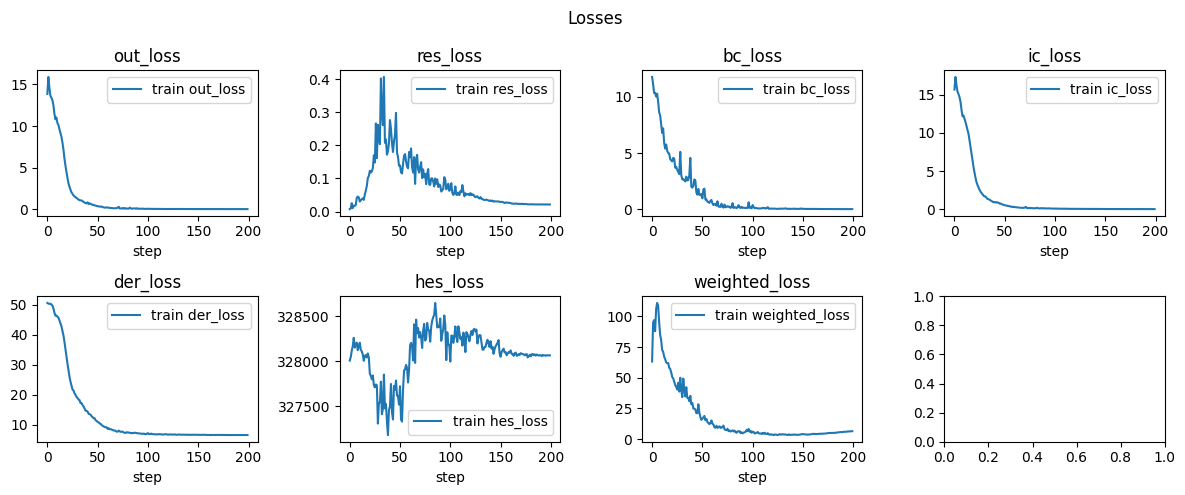


=============== Checkpoint ===============
PDE: Advection-Reaction-Diffusion
PDE parameters in input: []
Time in input: True
Space in input: True
Fourier features: -1
|Input units|: 3
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Std
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 71.69126892089844
	IC: 64.81356811523438
	RES: 55.507049560546875
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 87.808349609375
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 0.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
---------

In [6]:
subkeys = [
    "out_loss", 
    "der_loss", 
    "res_loss", 
    "hes_loss", 
    "bc_loss",
    "weighted_loss"
]
if IC_MODE == "Separated":
    subkeys.append("ic_loss")
if ACTION == "EWC":
    subkeys.append("ewc_loss")
        
for i, show in [(N_TASKS-1, True)]:
    models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{FOLDER}/T{i}/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    plot_model_stats_grid(
        data=f"{models_dir}/trial0",
        keys=["train"],
        subkeys=subkeys,
        figsize=(12, 5),
        title="Losses",
        save=SAVE_PLOTS,
        dst_file=f"{models_dir}/plots/losses.png",
        show=show
    )

    if show:
        print_model_info(f"{models_dir}/trial0")

Last bc_loss grad norm: 0.3252691626548767
Last ic_loss grad norm: 0.346910297870636
Last nl_loss grad norm: 0.31453898549079895
Last nl_bc_loss grad norm: 26.046457290649414
Last res_loss grad norm: 0.4401702582836151
Last grad norm: 0.9999997019767761


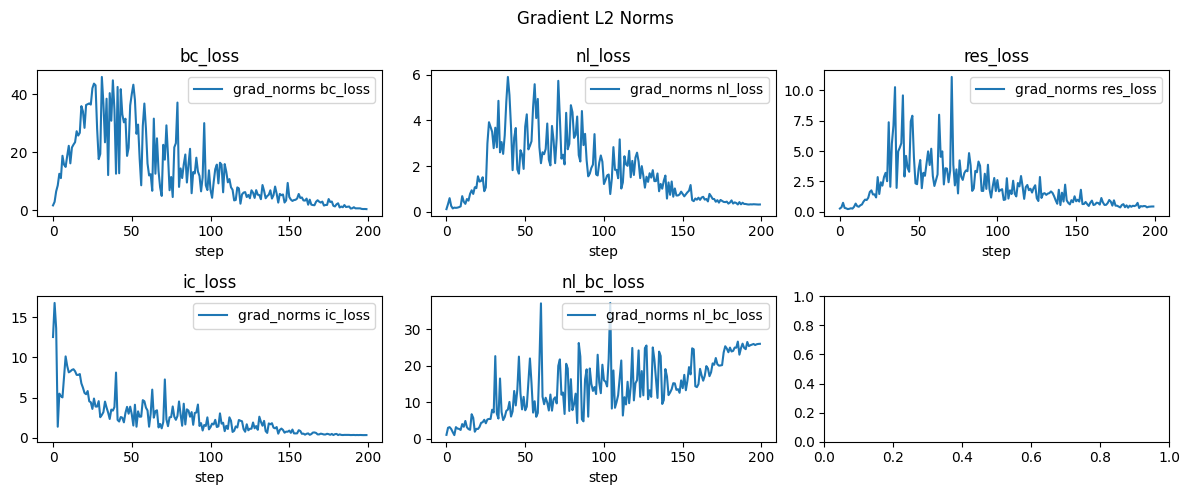

Last value weights res_loss: 55.507049560546875
Last value weights bc_loss: 71.69126892089844
Last value weights ic_loss: 64.81356811523438
Last value weights nl_loss: 87.808349609375
Last value weights nl_bc_loss: 1.065391182899475


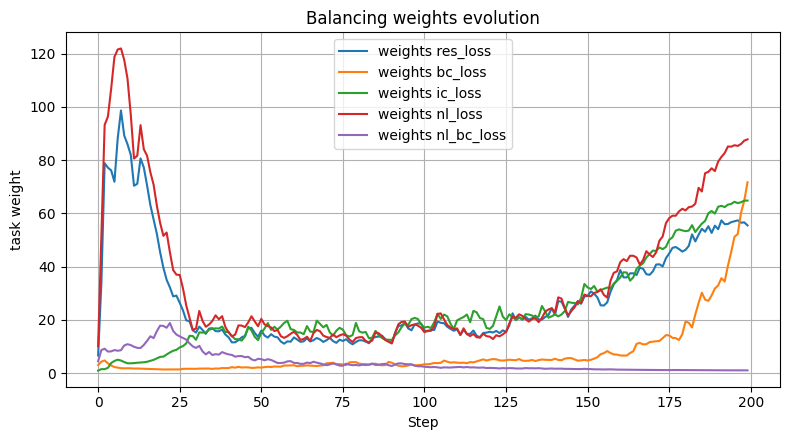

Last value conflicts bc_loss: -0.32869112491607666
Last value conflicts ic_loss: -0.1513066589832306
Last value conflicts nl_loss: -0.040291886776685715
Last value conflicts nl_bc_loss: -0.15401168167591095


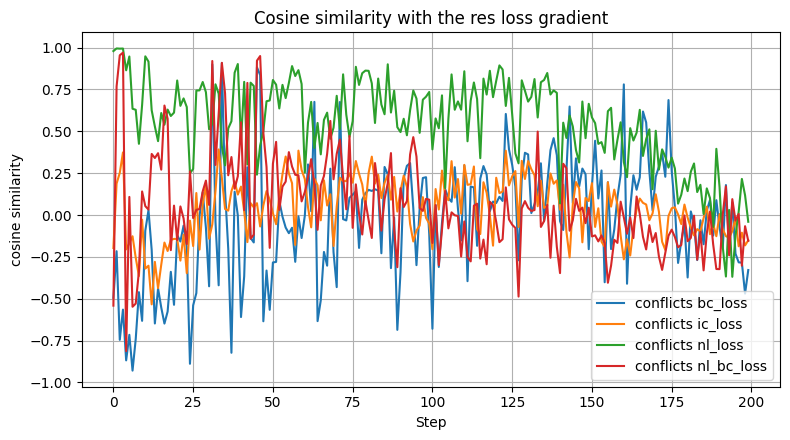

In [7]:
models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{FOLDER}/T{N_TASKS-1}/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models"
models_dict = {"trial0": load_stats(f"{models_dir}/trial0")}

if IC_MODE == "Separated":
    subkeys = ["bc_loss", "ic_loss"]
else:
    subkeys = ["bc_loss"]
    
if DISTILL:    
    items = DISTILL_MODE.split("+")
    if "Output" in items:
        subkeys.append("distill_out_loss")
    if "Derivative" in items:
        subkeys.append("distill_der_loss")
    if "Derivative_x" in items:
        subkeys.append("distill_derx_loss")
    if "Derivative_t" in items:
        subkeys.append("distill_dert_loss")
    if "Hessian" in items:
        subkeys.append("distill_hes_loss")
    if "Hessian_x" in items:
        subkeys.append("distill_hesx_loss")
    if "Hessian_t" in items:
        subkeys.append("distill_hest_loss")
        
if REPLAY:
    subkeys +=["nl_loss", "nl_bc_loss"]

for subkey in subkeys+["res_loss"]:
    print(f"Last {subkey} grad norm: {models_dict['trial0']['grad_norms'][subkey][-1]}")
print(f"Last grad norm: {models_dict['trial0']['train_loss_grad_norm'][-1][0]}")

if len(subkeys) > 2:
    if len(subkeys) > 3:
        figsize = (12, 5)
    else:
        figsize = (12, 3)
else:
    figsize = (12, 3)

for i, show in [(j+1, False) for j in range(N_TASKS-1)] + [(N_TASKS-1, True)]:
    models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{FOLDER}/T{i}/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    plot_model_stats_grid(
        data=f"{models_dir}/trial0",
        keys=["grad_norms"],
        subkeys=subkeys+["res_loss"],
        figsize=figsize,
        title="Gradient L2 Norms",
        save=SAVE_PLOTS,
        dst_file=f"{models_dir}/plots/grad_norms.png",
        show=show
    )
    
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["weights"],
    subkeys=["res_loss"]+subkeys,
    ylabel="task weight",
    title="Balancing weights evolution",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/weights.png"
)
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["conflicts"],
    subkeys=subkeys,
    ylabel="cosine similarity",
    title="Cosine similarity with the res loss gradient",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/conflicts.png"
)

### Predictions vs real values

In [8]:
def plot_points(
        dataset: str|TensorDataset|list,
        labels_idx: int|list = U,
        points_idx: int|list = X,
        labels_name: str|list = "u",
        save: bool = False,
        dst_file: str = "points.png",
        show: bool = True,
        cmap: str|list = "inferno",
        title: str = "",
        subtitles: list = [],
        single_row: bool = False,
        figsize: tuple = (5, 5),
        vmin: float|list = None,
        vmax: float|list = None
    ) -> None:
    """
    Plot the dataset(s) points, colored according to the label values.

    Parameters
    ----------
    dataset : str|TensorDataset|list
        The dataset filepath/TensorDataset object or TensorDataset list.
    labels_idx : int|list,
        Labels column index in the dataset(s).
    points_idx : int|list
        Spatial coordinates column index in the dataset(s).
    labels_name : str|list,
    save : bool
        If True, the plot is saved.
    dst_file : str
        Filepath where to save the plot.
    show : bool
        If True, the plot is showed.
    cmap : str|list
    title : str
    subtitles : list
    single_row : bool
    figsize : tuple
    vmin : float
    vmax : float
    
    Returns
    -------
    None
    """
    if type(dataset) is str:
        datasets = [torch.load(dataset, weights_only=False)]
    elif type(dataset) is list:
        datasets = []
        for ds in dataset:
            if type(ds) is str:
                datasets.append(torch.load(ds, weights_only=False))
            else:
                datasets.append(ds)
    else:
        datasets = [dataset]

    if type(labels_idx) is int:
        labels_idx = [labels_idx for _ in datasets]
    if type(labels_name) is str:
        names = [labels_name for _ in datasets]
    else:
        names = labels_name
    if type(points_idx) is int:
        points_idx = [points_idx for _ in datasets]
    pointss = [dataset.tensors[i] for dataset, i in zip(datasets, points_idx)]
    labelss = []
    if type(cmap) is str:
        cmaps = []
        for dataset, i in zip(datasets, labels_idx):
            if i > -1:
                labelss.append(dataset.tensors[i])
                cmaps.append(cmap)
            else:
                labelss.append(torch.zeros_like(dataset.tensors[U]))
                cmaps.append("grey")
    else:
        cmaps = cmap
        for dataset, i in zip(datasets, labels_idx):
            labelss.append(dataset.tensors[i])

    if vmin is None or type(vmin) is float:
        vmins = [vmin for _ in datasets]
        vmaxs = [vmax for _ in datasets]
    else:
        vmins = vmin
        vmaxs = vmax

    font = {'size': 10}
    matplotlib.rc('font', **font)
    fig = plt.figure(figsize=figsize)

    if len(labels_idx) <= 4 or single_row:
        gs = GridSpec(1, len(labels_idx), figure=fig)
        axes = [fig.add_subplot(gs[0, i]) for i in range(len(labels_idx))]
    elif len(labels_idx) <= 8:
        ncols = int(np.ceil(len(labels_idx)/2))
        gs = GridSpec(2, ncols, figure=fig)
        axes = []
        for i in range(ncols):
            axes.append(fig.add_subplot(gs[0, i]))
            axes.append(fig.add_subplot(gs[1, i]))
    elif len(labels_idx) <= 16:
        ncols = int(np.ceil(len(labels_idx)/3))
        gs = GridSpec(3, ncols, figure=fig)
        axes = []
        for i in range(ncols):
            axes.append(fig.add_subplot(gs[0, i]))
            axes.append(fig.add_subplot(gs[1, i]))
            axes.append(fig.add_subplot(gs[2, i]))
    elif len(labels_idx) <= 24:
        ncols = int(np.ceil(len(labels_idx)/4))-1
        gs = GridSpec(5, ncols, figure=fig)
        axes = []
        for i in range(ncols):
            axes.append(fig.add_subplot(gs[0, i]))
            axes.append(fig.add_subplot(gs[1, i]))
            axes.append(fig.add_subplot(gs[2, i]))
            axes.append(fig.add_subplot(gs[3, i]))
            axes.append(fig.add_subplot(gs[4, i]))
    else:
        raise ValueError("Too many plots.")
    
    if subtitles == []:
        subtitles = ["" for _ in axes]
    for ax, points, labels, name, cmap, vmin, vmax, subtitle in zip(axes, pointss, labelss, names, cmaps, vmins, vmaxs, subtitles):
        if vmin is not None and vmax is not None:
            scatter = ax.scatter(points[:, 0], points[:, 1], s=1, alpha=1, c=labels.flatten(), cmap=cmap, vmin=vmin, vmax=vmax)
        else:
            scatter = ax.scatter(points[:, 0], points[:, 1], s=1, alpha=1, c=labels.flatten(), cmap=cmap)

        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label(name)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        if subtitle != "":
            ax.set_title(subtitle)
        
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.plot()
    fig.subplots_adjust(right=0.85, wspace=0.5, hspace=0.5) 
    fig.suptitle(title)
    plt.tight_layout()
    if save:
        plt.savefig(fname=dst_file, bbox_inches='tight', dpi=300)
    if show:
        plt.show()
    else:
        plt.close()

Params 0


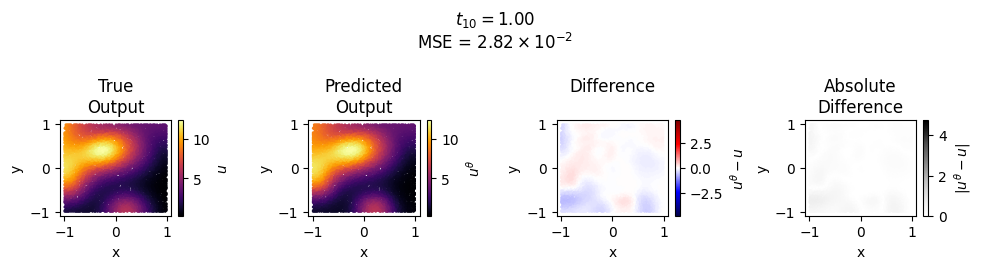

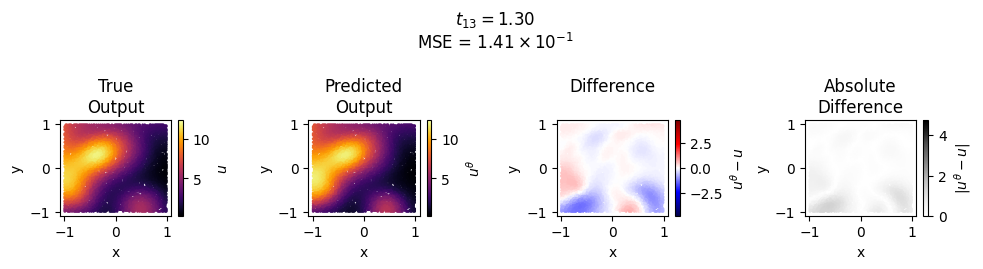

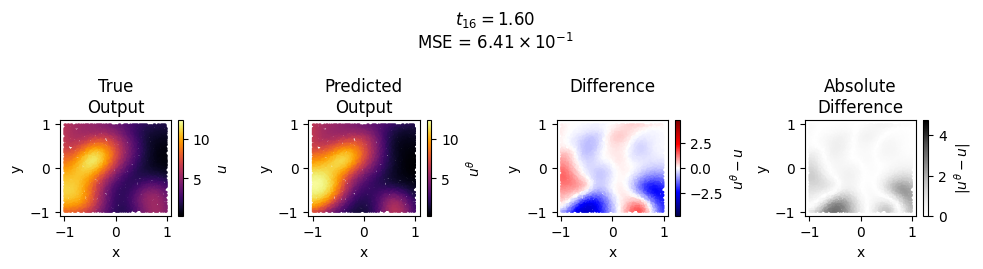

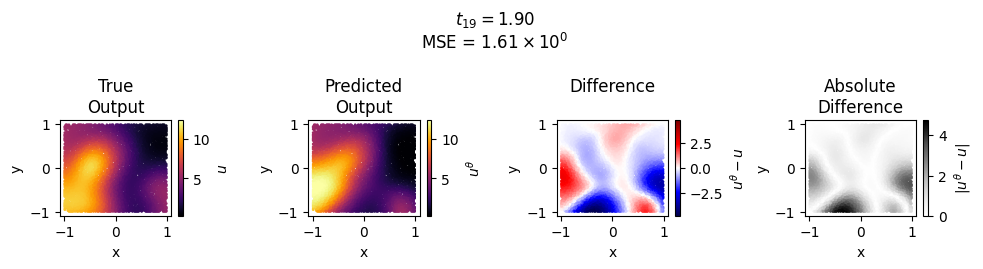

In [10]:
CROSS_THE_RUBICON = True
if CROSS_THE_RUBICON:
    times = [0, 3, 6, 9]
    param_indices = [0] # [D_INDEX] [IC_INDEX]
    data_path = DATA2
    S = 2
    dt = 10

    if "IC" in FIXED and "D" in FIXED:
        param_indices = [INDEX]

    if dev_dataset is not None:
        del dev_dataset
        dev_dataset = None
    datasets = torch.load(f"{PDE}/{data_path}/full_datasets.pth", weights_only=False).datasets

    trues = [[[] for t in range(max(times)+1)] for i in range(max(param_indices)+1)]
    
    for i in param_indices:
        trues[i] = datasets[i].datasets
    del datasets

    models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{FOLDER}/T{N_TASKS-1}/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")

    vmins = []
    vmaxs = []

    for i in param_indices:
        vmins.append(min([trues[i][t].tensors[U].min() for t in times]))
        vmaxs.append(max([trues[i][t].tensors[U].max() for t in times]))
    vmin = min(vmins)
    vmax = max(vmaxs)

    differences = [[[] for t in range(max(times)+1)] for i in range(max(param_indices)+1)]
    for i in param_indices:
        for t in times:
            differences[i][t] = compute_prediction_difference(model=best_model, dataset=trues[i][t], signed=True)

    vmins = []
    vmaxs = []

    for i in param_indices:
        vmins.append(min([differences[i][t].tensors[U].min() for t in times]))
        vmaxs.append(max([differences[i][t].tensors[U].max() for t in times]))
    vmin_diff = min(vmins)
    vmax_diff = max(vmaxs)
    v_diff = max(abs(vmin_diff), abs(vmax_diff))

    figsize = (10, 2.7)
    
    for i in param_indices:
        print(f"Params {i}")
        for t in times:
            prediction = compute_prediction(model=best_model, dataset=trues[i][t])
            abs_difference = compute_prediction_difference(model=best_model, dataset=trues[i][t], signed=False)
            
            mean_abs_difference = torch.mean(abs_difference.tensors[U]**2)
            mae = mean_abs_difference.item()
            
            value = format(mae, ".2e").split('e')[0]
            exponent = format(mae, ".2e").split('e')[1]
            plot_points(
                dataset=[trues[i][t], prediction, differences[i][t], abs_difference],
                points_idx=X,
                labels_idx=U,
                cmap=["inferno", "inferno", "seismic", "Greys"],
                figsize=figsize,
                vmin=2*[vmin]+[-v_diff]+[0],
                vmax=2*[vmax]+[v_diff]+[v_diff],
                title=f"$t_{{{dt+t}}} = {{{trues[i][t].tensors[TIMES][0].item():.2f}}}$\nMSE = ${{{value}}} \\times 10^{{{int(exponent)}}}$",
                subtitles=["True\nOutput", "Predicted\nOutput", "Difference\n", "Absolute\nDifference"],
                labels_name=[r"$u$", r"$u^{\theta}$", r"$u^{\theta} - u$", r"$|u^{\theta} - u|$"],
                save=SAVE_PLOTS,
                dst_file=f"{models_dir}/plots/Task{i}Time{t}_{S}.png",
                show=True
            )
            del prediction
            del abs_difference
    del trues
    del differences

In [ ]:
indices = {}
for s in ["intra_test"]:
    if INDEX is None:
        indices[s] = torch.load(f"{PDE}/{DATA}/{s}_indices.pth")
    else:
        indices[s] = [torch.load(f"{PDE}/{DATA}/{s}_indices.pth")[INDEX]]

if INDEX is None:
    full_dataset = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets
else:
    full_dataset = [torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets[INDEX]]

#intra_test_dataset = load_datasets(full_dataset, indices["intra_test"], TIME_RESOLUTION)

del full_dataset    

for model_index in [N_TASKS-1]:
    models_dirs = [
        f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS_FULL}/models2",
        f"{PDE}/TimeIncrementalLearning/{DIR}/{FOLDER}/T{model_index}/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models"
    ]
    models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
    models_names = ["Mfull", f"M{model_index}"]
    
    #for datasets, name, dst in zip([train_datas, intra_test_datas, [inter_test_data]], 
    #                               ["train", "intra_test", "inter_test"], 
    #                               ["train_dataset", "intra_test_dataset", "inter_test_dataset"]
    #                               ):
    #    for i, dataset in tqdm(enumerate(datasets), total=len(datasets)):
    #        os.makedirs(f"{models_dirs[-1]}/plots/{dst}", exist_ok=True)
    #        dst_file = [f"{models_dirs[-1]}/plots/{dst}/full_comparison_task{i}.png"]
#
    #        plot_performance_comparison(
    #            models=models,
    #            models_names=models_names,
    #            datasets=[dataset],
    #            datasets_names=[f"{name}{i}"],
    #            subset={"x": [-1.0, 1.0], "y": [-1.0, 1.0]},
    #            figsize=(11, 3),
    #            bar_labels=True,
    #            yaxis_visible=True,
    #            colors=["firebrick", "tab:blue"],
    #            save=SAVE_PLOTS,
    #            dst_files=dst_file,
    #            show=False
    #        )

    names = ["intra_test"]
    for name in names:
        os.makedirs(f"{models_dirs[-1]}/plots/{name}", exist_ok=True)
    dst_files = [f"{models_dirs[-1]}/plots/intra_test/full_comparison_allTasks.png"]
    plot_performance_comparison(
        models=models,
        models_names=models_names,
        datasets=intra_test_dataset,
        datasets_names=names,
        time_indexes=list(range(10)),
        subset={"x": [-1.0, 1.0], "y": [-1.0, 1.0]},
        figsize=(18, 3),
        bar_labels=True,
        yaxis_visible=True,
        colors=["firebrick", "tab:blue"],
        save=SAVE_PLOTS,
        dst_files=dst_files,
        show=True
    )

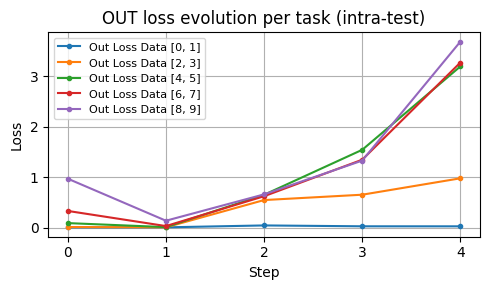

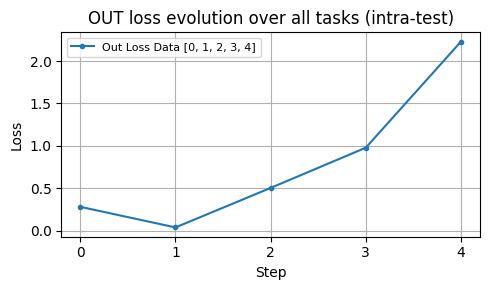

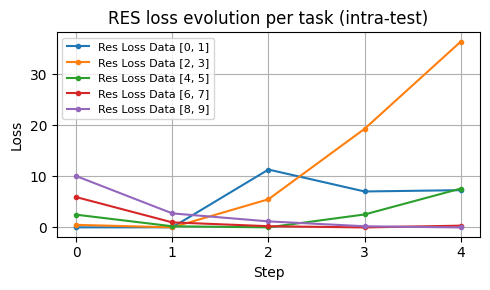

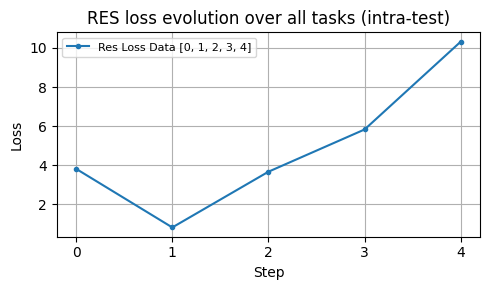

In [ ]:
prefix = f"{PDE}/TimeIncrementalLearning/{DIR}/{FOLDER}"
suffix = f"{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models/trial0/model.pth"

prefix0 = f"{PDE}/TimeIncrementalLearning/{DIR0}"
suffix0 = f"{ACTUAL_MODE0}_{TRAIN_BC}{BC_MODE0}BC_{LR_MODE0}_{DWA_MODE}_{CLIP}_{N_EPOCHS0}/models2/trial0/model.pth"

models = [f"{prefix0}/{suffix0}"] + [f"{prefix}/T{i+1}/{suffix}" for i in range(N_TASKS-1)]

datass = [
    [extract_TensorDataset(prepare_dataset(intra_test_dataset, TRAIN_TIME_INDEXESS[i][1:])) for i in range(N_TASKS)],
    #[extract_TensorDataset(intra_test_dataset[0].datasets[i]) for i in range(N_TIME_SAMPLES)],
    [extract_TensorDataset(prepare_dataset(intra_test_dataset))]
]
data_idss = [
    [TRAIN_TIME_INDEXESS[i][1:] for i in range(N_TASKS)],
    [[i for i in range(N_TASKS)]]
]

for s in ["out", "res"]:
    title_start = f"{s.upper()} loss evolution"
    titles = [
        title_start + " per task (intra-test)",
        title_start + " over all tasks (intra-test)"
    ]
    filenames = [
        f"intra_test_{s}_loss_per_task",
        f"intra_test_{s}_loss_all_tasks"
    ]

    plot_dir = f"{prefix}/ForgetPlots/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}"
    os.makedirs(plot_dir, exist_ok=True)
    for datas, data_ids, title, filename in zip(datass, data_idss, titles, filenames):
        plot_loss(
            model_sequence=models,
            losses=[s],
            data_sequence=datas,
            data_ids=data_ids,
            title=title,
            save=SAVE_PLOTS,
            dst_file=f"{plot_dir}/{filename}.png",
            figsize=(5, 3),
            legend_fontsize=8
        )
del datass

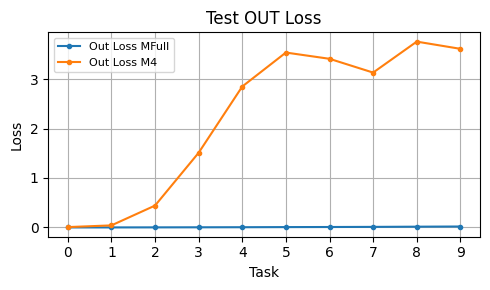

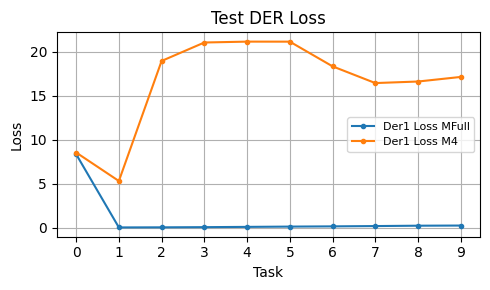

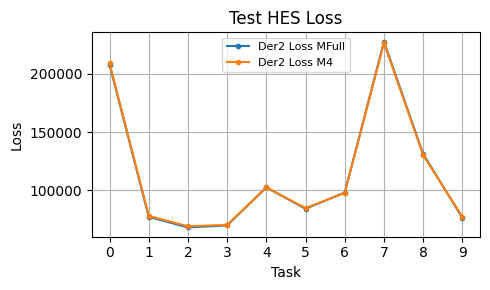

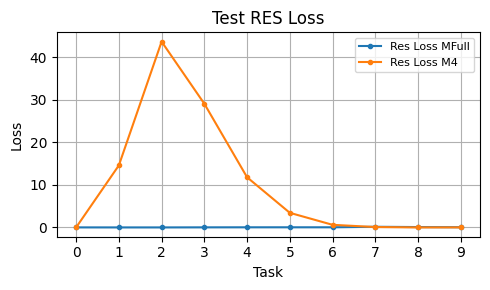

In [ ]:
prefix = f"{PDE}/TimeIncrementalLearning/{DIR}/{FOLDER}"
suffix = f"{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models/trial0/model.pth"

models = [
    f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS_FULL}/models2/trial0/model.pth",
    f"{prefix}/T{N_TASKS-1}/{suffix}"
]

datas = [extract_TensorDataset(intra_test_data) for intra_test_data in intra_test_dataset[0].datasets]

for s in ["out", "der", "hes", "res"]:
    title = f"Test {s.upper()} Loss"

    plot_dir = f"{prefix}/T{N_TASKS-1}/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models/plots/intra_test"
    filename = f"{s}_lossA.png"
    os.makedirs(plot_dir, exist_ok=True)

    plot_time_losses(
        models=models,
        model_labels=["MFull", f"M{N_TASKS-1}"],
        loss=s,
        datas=datas,
        title=title,
        save=SAVE_PLOTS,
        dst_file=f"{plot_dir}/{filename}",
        figsize=(5, 3),
        legend_fontsize=8
    )
del datas

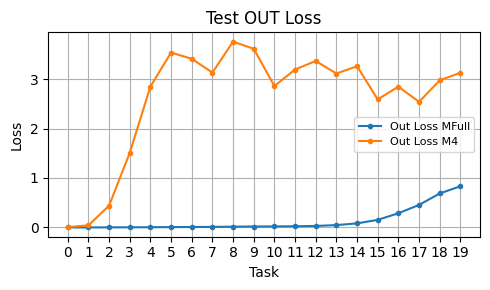

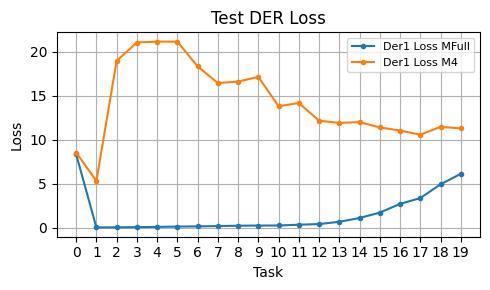

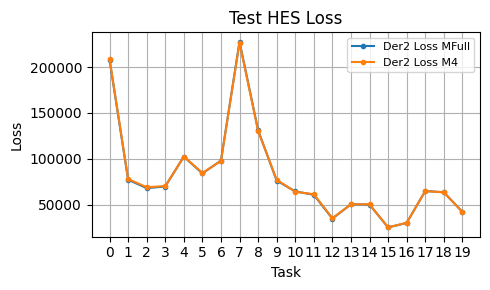

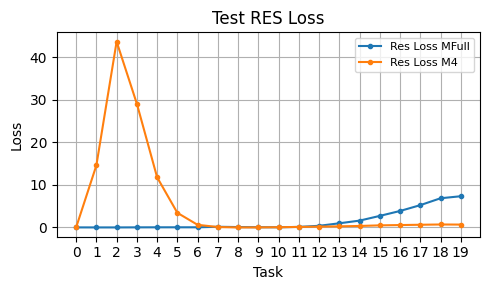

In [ ]:
if INDEX is None:
    full_dataset = torch.load(f"{PDE}/{DATA2}/full_datasets.pth", weights_only=False).datasets
else:
    full_dataset = [torch.load(f"{PDE}/{DATA2}/full_datasets.pth", weights_only=False).datasets[INDEX]]

intra_test_dataset2 = load_datasets(full_dataset, indices["intra_test"], TIME_RESOLUTION)

del full_dataset
full_dataset = None


prefix = f"{PDE}/TimeIncrementalLearning/{DIR}/{FOLDER}"
suffix = f"{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models/trial0/model.pth"

models = [
    f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS_FULL}/models2/trial0/model.pth",
    f"{prefix}/T{N_TASKS-1}/{suffix}"
]

datas = [extract_TensorDataset(intra_test_data) for intra_test_data in intra_test_dataset[0].datasets+intra_test_dataset2[0].datasets]

for s in ["out", "der", "hes", "res"]:
    title = f"Test {s.upper()} Loss"

    plot_dir = f"{prefix}/T{N_TASKS-1}/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models/plots/intra_test"
    filename = f"{s}_lossB.png"
    os.makedirs(plot_dir, exist_ok=True)

    plot_time_losses(
        models=models,
        model_labels=["MFull", f"M{N_TASKS-1}"],
        loss=s,
        datas=datas,
        logscale=False,
        title=title,
        save=SAVE_PLOTS,
        dst_file=f"{plot_dir}/{filename}",
        figsize=(5, 3),
        legend_fontsize=8
    )
del datas